# Throughput bench — Allen RK vs extrapUTT vs PINN_V2 (exploration)

Per-track extrapolation **throughput** (not accuracy). Tier-1 = isolated CUDA micro-bench
(NVRTC-compiled verbatim Allen device code, CUDA-event timing); Tier-2 = CPU in-situ
reality check on the real `extrapUTT` vs `pinn_v2_utt_state`. See `gates/baseline/throughput.json`.

In [1]:
%matplotlib inline
import json, os
import numpy as np
import matplotlib.pyplot as plt
REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
T = json.load(open(os.path.join(REPO, 'gates', 'baseline', 'throughput.json')))
art = os.path.join(REPO, 'allen_bridge', 'bench', 'artifacts')
inp = np.load(os.path.join(art, 'bench_inputs.npz'))
meta = json.load(open(os.path.join(art, 'inputs_meta.json')))
print('unit:', T['unit'])
print('headline ratios:', json.dumps(T['headline_ratios_kernel_only'], indent=2))
print('outcome :', T['outcome'])
print('decision:', T['decision'])

unit: one track, one extrapolation across its given dz (state->state)
headline ratios: {
  "RK_div_NN": 0.81,
  "extrapUTT_div_NN": 0.332,
  "RK_div_extrapUTT": 2.44,
  "RK_div_chart": null
}
outcome : comparable speed
decision: methods paper (case rests on footprint + cautionary-tale science)


## 1 · The driving population (confound #4): real gen-4 (z0, dz, p)

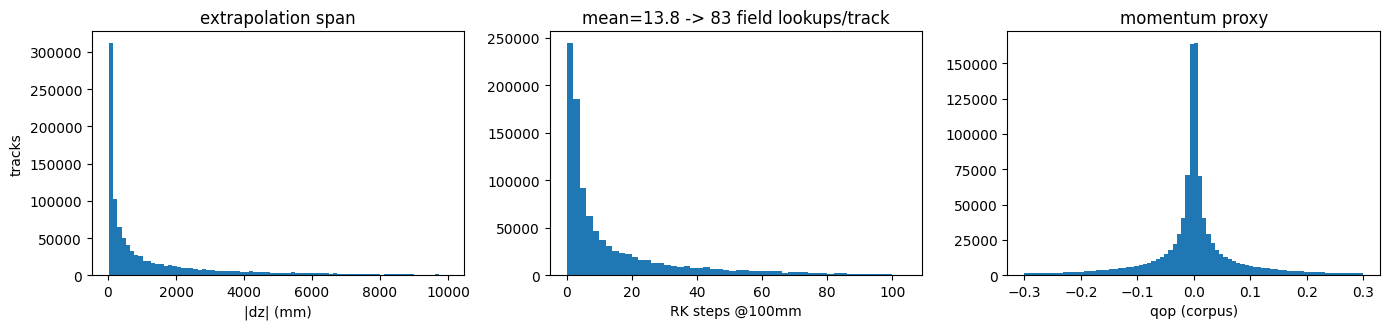

RK step stats: {'mean': 13.792181015014648, 'median': 5.0, 'p99': 86.0, 'max': 100.0}


In [2]:
dz = inp['dz']; p = None
steps = np.ceil(np.abs(dz)/100.0)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].hist(np.abs(dz), bins=80); ax[0].set_xlabel('|dz| (mm)'); ax[0].set_ylabel('tracks'); ax[0].set_title('extrapolation span')
ax[1].hist(steps, bins=np.arange(0, 105, 2)); ax[1].set_xlabel('RK steps @100mm'); ax[1].set_title(f'mean={steps.mean():.1f} -> {6*steps.mean():.0f} field lookups/track')
ax[2].hist(inp['qop'], bins=80); ax[2].set_xlabel('qop (corpus)'); ax[2].set_title('momentum proxy')
plt.tight_layout(); plt.show()
print('RK step stats:', meta['population']['rk_steps_at_100mm'])

## 2 · Headline throughput (kernel-only median)

method           us/track      tracks/s  1-warp us  rel_iqr%
rk_field          0.00571     1.752e+08     11.264      1.68
extraputt         0.00234     4.265e+08     23.552      0.75
pinn_v2_utt       0.00705     1.418e+08    176.128      0.20


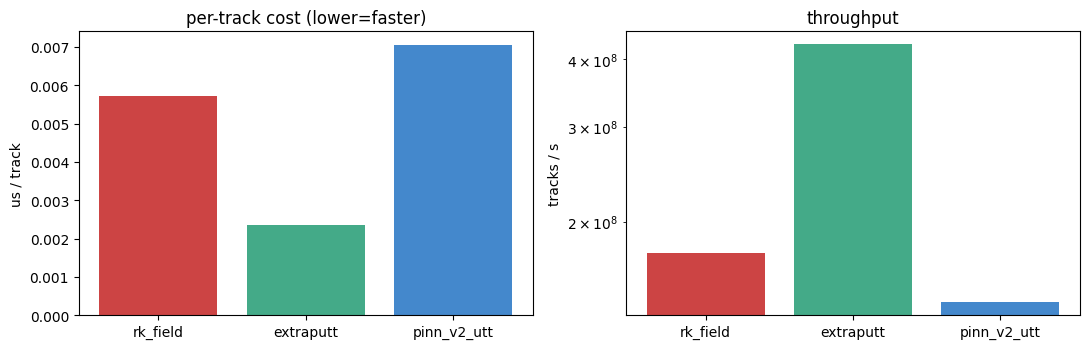

In [3]:
M = T['methods_kernel_only']
names = list(M.keys())
print(f"{'method':14s} {'us/track':>10s} {'tracks/s':>13s} {'1-warp us':>10s} {'rel_iqr%':>9s}")
for k in names:
    print(f"{k:14s} {M[k]['us_per_track']:10.5f} {M[k]['tracks_per_s']:13.3e} {M[k]['single_warp_us_median']:10.3f} {M[k]['kernel_only_rel_iqr_pct']:9.2f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(names, [M[k]['us_per_track'] for k in names], color=['#c44','#4a8','#48c']); ax[0].set_ylabel('us / track'); ax[0].set_title('per-track cost (lower=faster)')
ax[1].bar(names, [M[k]['tracks_per_s'] for k in names], color=['#c44','#4a8','#48c']); ax[1].set_ylabel('tracks / s'); ax[1].set_yscale('log'); ax[1].set_title('throughput')
plt.tight_layout(); plt.show()

## 3 · Speedup ratios + footprint co-metric (#3)

In [4]:
print('speedup ratios (kernel-only):', json.dumps(T['headline_ratios_kernel_only'], indent=2))
fc = T['footprint_co_metric']
print('\nfootprints:')
for k in ['field_map_texture_MB','extraputt_chart_KB','pinn_v2_weights_KB']:
    print(f'  {k:24s} {fc[k]}')
print('  field/NN footprint ratio:', fc['field_vs_nn_ratio'], 'x')

speedup ratios (kernel-only): {
  "RK_div_NN": 0.81,
  "extrapUTT_div_NN": 0.332,
  "RK_div_extrapUTT": 2.44,
  "RK_div_chart": null
}

footprints:
  field_map_texture_MB     11.495
  extraputt_chart_KB       960.1
  pinn_v2_weights_KB       41.5
  field/NN footprint ratio: 276.8 x


## 4 · Validity gates + Tier-1/Tier-2 cross-check (#12)

In [5]:
print(json.dumps(T['validity_gates'], indent=2))

{
  "stability_lt_5pct": {
    "pass": true,
    "worst_rel_iqr_pct": 1.681
  },
  "tier1_tier2_crosscheck": {
    "status": "platform-divergent-by-design (see interpretation)",
    "tier1_extrapUTT_div_PINN_GPU": 0.3323,
    "tier2_extrapUTT_div_PINN_CPU": 0.0225,
    "agreement_factor": 14.78,
    "within_2x_literal": false,
    "interpretation": "extrapUTT/RK are memory-bound, the NN is compute-bound; the CPU (scalar) and GPU (parallel) platforms have opposite compute:bandwidth balance, so the extrapUTT:PINN cost ratio legitimately differs across tiers. The built Allen is CPU-only (TARGET_DEVICE=CPU), so a same-platform in-situ GPU comparison is not available. Tier-2's role is therefore: (a) confirm the verbatim production functions run correctly on the real population, (b) show the NN's throughput competitiveness is a GPU phenomenon. The headline RK/NN number is Tier-1 (GPU)."
  },
  "rk_reproduces_allen_per_event": "see write-up external-validity section",
  "chart_struct_abi_self

## 5 · The 12-point confound checklist (filled with actual values)

In [6]:
for k, v in T['confound_checklist_12'].items():
    print(f"[{k}]\n  control: {v['control']}\n  value  : {json.dumps(v['value'])[:300]}\n")

[1_hardware_variance]
  control: single exclusive GPU slot (request_gpus=1, request_cpus=1, request_memory=8GB); record model + SM clock; no co-tenants
  value  : {"gpu": "Tesla V100-PCIE-32GB", "driver": "13.0", "compute_capability": "7.0", "sm_clock_MHz": 1380.0, "machine": "wn-lot-008.nikhef.nl", "clock_source": "condor machine classad (nvidia-smi not on worker PATH); clock is the advertised SM clock", "clock_locking": "not permitted on shared pool (record

[2_cold_cache_jit]
  control: >=200 warm-up iters discarded; >=30 timed repeats; median + IQR (never single/mean)
  value  : {"warmup_iters": 200, "timed_repeats": 50, "reported": "median + IQR", "worst_rel_iqr_pct": 1.681}

[3_host_clock_noise]
  control: CUDA events around the kernel, cudaDeviceSynchronize bracketing (not Python/wall time)
  value  : "CUDA events (cudaEventElapsedTime), device-synchronised per repeat"

[4_unrealistic_population]
  control: drive all methods with the real gen-4 (z0,dz,p) distribution; throughput